# **Import Library**

In [ ]:
import numpy as np
from numpy.linalg import norm
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import cosine_similarity
import random
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score, silhouette_score, calinski_harabasz_score
from sklearn.metrics import mean_squared_error

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.decomposition import PCA

from ast import literal_eval

# **Import Data**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pathRatings = "/content/drive/Shareddrives/R Python - Nhóm 5/Final Project/EDA/ratings200k.csv"
dfRatings = pd.read_csv(pathRatings)
dfRatings.head(3)

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523


In [ ]:
path5000Movie = "/content/drive/Shareddrives/R Python - Nhóm 5/Final Project/EDA/tmdb_5000_movies.csv"
df5000Movie = pd.read_csv(path5000Movie)
df5000Movie.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [ ]:
path5000MovieCredit = "/content/drive/Shareddrives/R Python - Nhóm 5/Final Project/EDA/tmdb_5000_credits.csv"
df5000MovieCredit = pd.read_csv(path5000MovieCredit)
df5000MovieCredit.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


# **Data Understanding**

In [ ]:
print("Ratings Dataframe Shape:", dfRatings.shape)
print("\nRatings Dataframe Information:", dfRatings.info())
print("\nRatings Dataframe Description:", dfRatings.describe())
print("\nRatings Dataframe Missing Values:", dfRatings.isnull().sum())

Ratings Dataframe Shape: (300181, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300181 entries, 0 to 300180
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     300181 non-null  int64  
 1   movieId    300181 non-null  int64  
 2   rating     300181 non-null  float64
 3   timestamp  300181 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 9.2 MB

Ratings Dataframe Information: None

Ratings Dataframe Description:               userId        movieId         rating     timestamp
count  300181.000000  300181.000000  300181.000000  3.001810e+05
mean     1571.070607   16380.775795       3.548702  1.179798e+09
std       914.367845   31639.969444       1.035709  2.050535e+08
min         1.000000       1.000000       0.500000  8.279472e+08
25%       773.000000    1076.000000       3.000000  1.000406e+09
50%      1572.000000    2640.000000       3.500000  1.172691e+09
75%      2422.000000    6708.0000

In [ ]:
print("5000Movie Dataframe Shape:", df5000Movie.shape)
print("\n5000Movie Dataframe Information:", df5000Movie.info())
print("\n5000Movie Dataframe Description:", df5000Movie.describe())
print("\n5000Movie Dataframe Missing Values:", df5000Movie.isnull().sum())

5000Movie Dataframe Shape: (4803, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-nul

In [ ]:
print("5000MovieCredit Dataframe Shape:", df5000MovieCredit.shape)
print("\n5000MovieCredit Dataframe Information:", df5000MovieCredit.info())
print("\n5000MovieCredit Dataframe Description:", df5000MovieCredit.describe())
print("\n5000MovieCredit Dataframe Missing Values:", df5000MovieCredit.isnull().sum())

5000MovieCredit Dataframe Shape: (4803, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB

5000MovieCredit Dataframe Information: None

5000MovieCredit Dataframe Description:             movie_id
count    4803.000000
mean    57165.484281
std     88694.614033
min         5.000000
25%      9014.500000
50%     14629.000000
75%     58610.500000
max    459488.000000

5000MovieCredit Dataframe Missing Values: movie_id    0
title       0
cast        0
crew        0
dtype: int64


# **EDA**

Mean rating: 3.54870228295595
Median rating: 3.5
Standard deviation of ratings: 1.0357093576820982


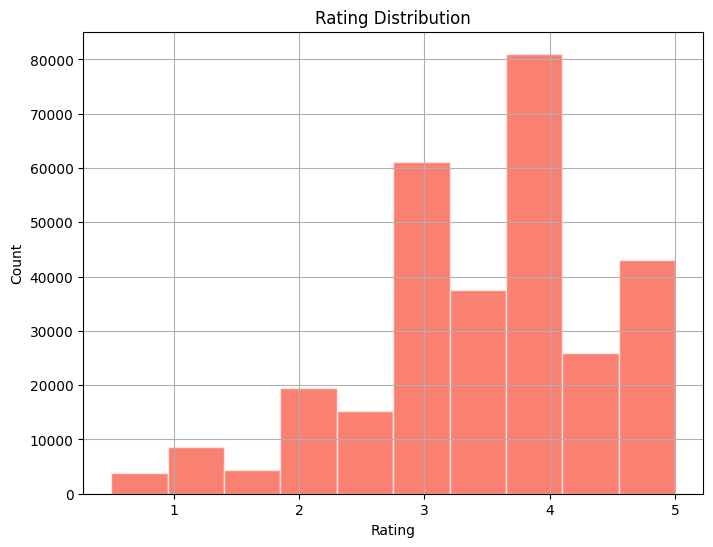

In [ ]:
mean_rating = dfRatings['rating'].mean()
median_rating = dfRatings['rating'].median()
std_dev_rating = dfRatings['rating'].std()
print("Mean rating:", mean_rating)
print("Median rating:", median_rating)
print("Standard deviation of ratings:", std_dev_rating)

plt.figure(figsize=(8, 6))
plt.hist(dfRatings['rating'], bins=10, color='salmon', edgecolor='mistyrose')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [ ]:
# Analyzing ratings by user and by movie
user_ratings_count = dfRatings.groupby('userId')['rating'].count()
movie_ratings_count = dfRatings.groupby('movieId')['rating'].count()

top_10_users = user_ratings_count.nlargest(10)
top_10_movies = movie_ratings_count.nlargest(10)
print("Top 10 users with most ratings:", top_10_users)
print("\nTop 10 movies with most ratings:", top_10_movies)

Top 10 users with most ratings: userId
741     2811
2547    1951
2531    1928
2520    1784
1932    1767
2975    1555
836     1521
1846    1484
3140    1484
2885    1359
Name: rating, dtype: int64

Top 10 movies with most ratings: movieId
318     1107
356     1088
296     1040
593      990
2571     945
480      918
260      912
1        848
527      796
589      786
Name: rating, dtype: int64


<Figure size 1000x600 with 0 Axes>

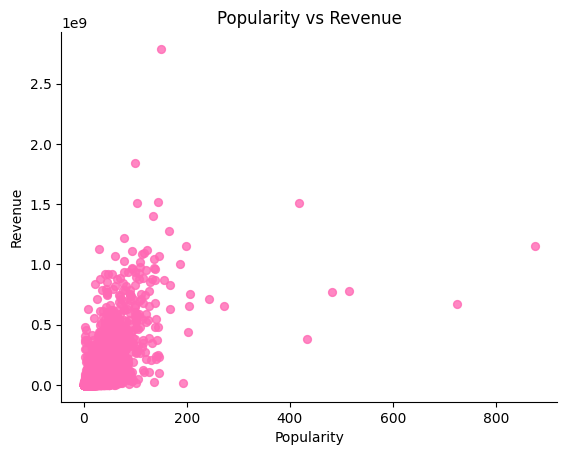

In [ ]:
plt.figure(figsize=(10, 6))
df5000Movie.plot(kind='scatter', x='popularity', y='revenue', s=32, alpha=0.8, color='hotpink')
plt.title('Popularity vs Revenue')
plt.xlabel('Popularity')
plt.ylabel('Revenue')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

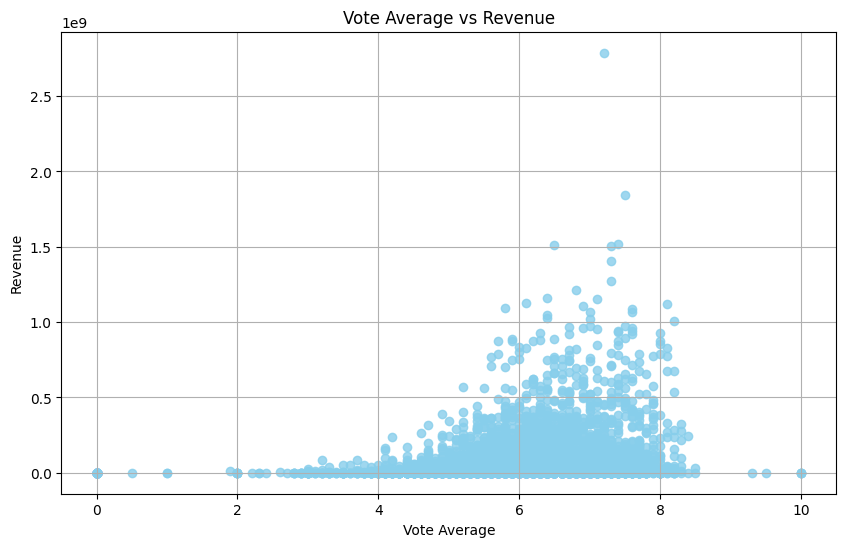

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df5000Movie['vote_average'], df5000Movie['revenue'], color='skyblue', alpha=0.8)
plt.title('Vote Average vs Revenue')
plt.xlabel('Vote Average')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

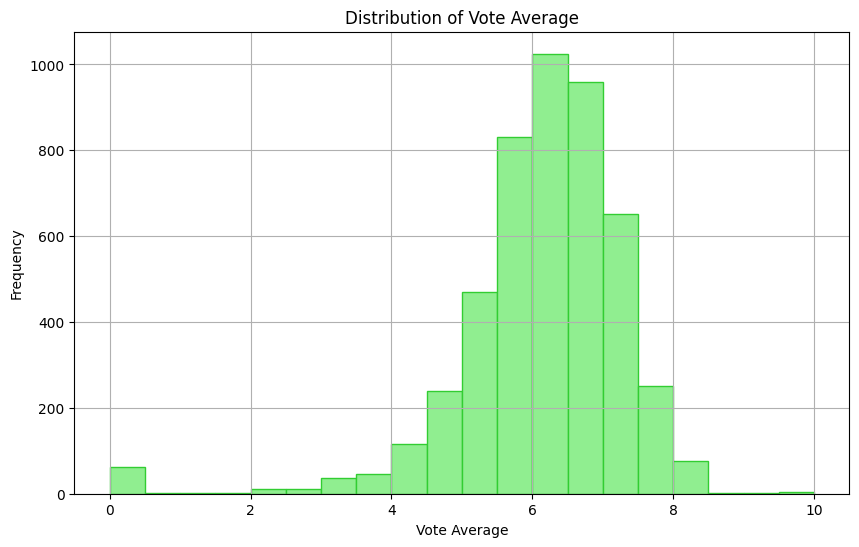

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df5000Movie['vote_average'], bins=20, color='lightgreen', edgecolor='limegreen')
plt.title('Distribution of Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

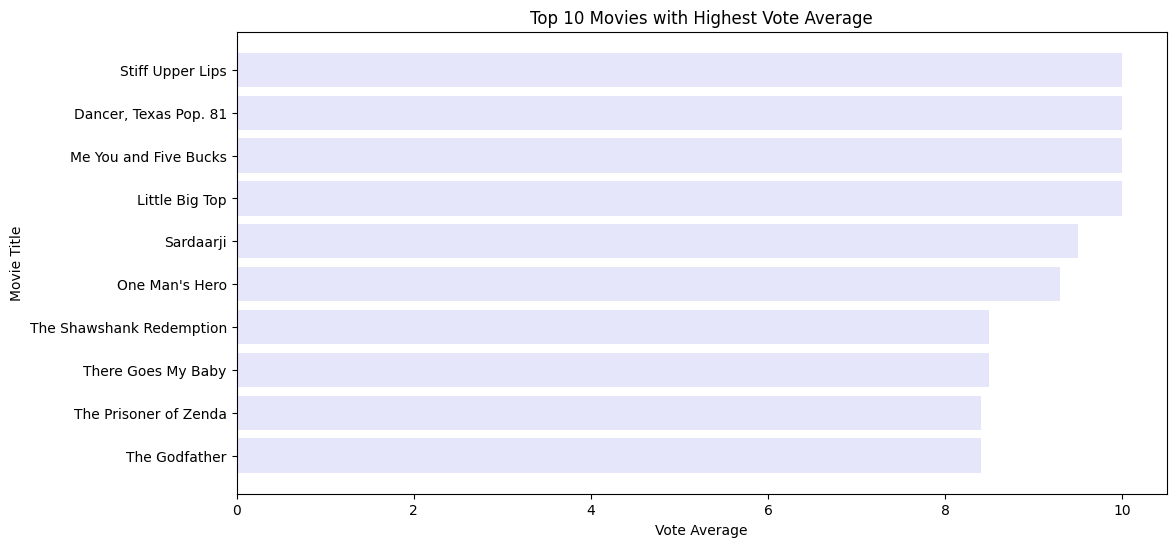

In [ ]:
top_10_high_rated_movies = df5000Movie.nlargest(10, 'vote_average')

plt.figure(figsize=(12, 6))
plt.barh(top_10_high_rated_movies['original_title'], top_10_high_rated_movies['vote_average'], color='lavender')
plt.xlabel('Vote Average')
plt.ylabel('Movie Title')
plt.title('Top 10 Movies with Highest Vote Average')
plt.gca().invert_yaxis()
plt.show()

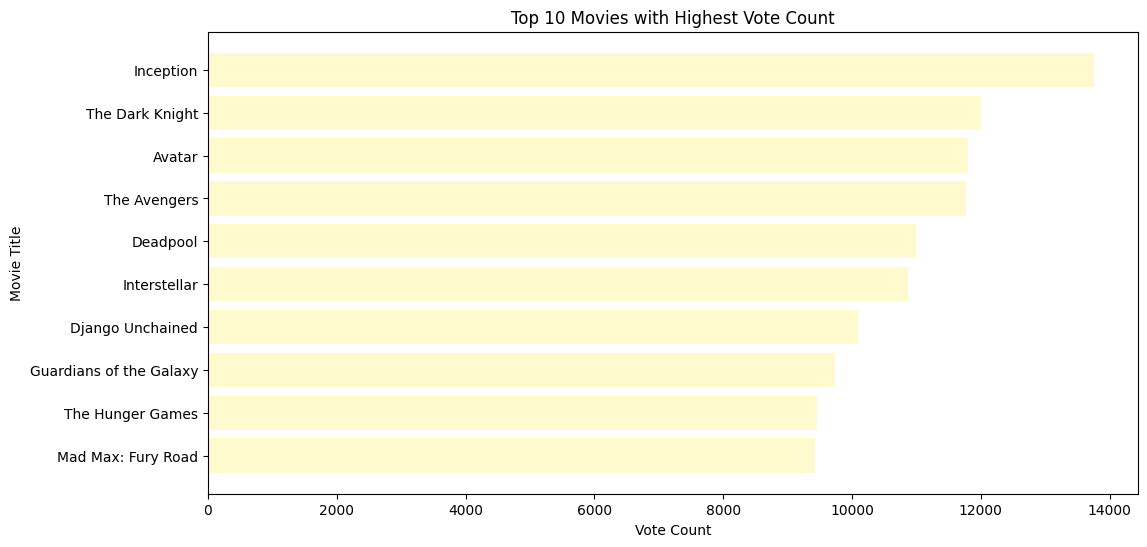

In [ ]:
top_10_most_voted_movies = df5000Movie.nlargest(10, 'vote_count')

plt.figure(figsize=(12, 6))
plt.barh(top_10_most_voted_movies['original_title'], top_10_most_voted_movies['vote_count'], color='lemonchiffon')
plt.xlabel('Vote Count')
plt.ylabel('Movie Title')
plt.title('Top 10 Movies with Highest Vote Count')
plt.gca().invert_yaxis()
plt.show()

Text(0.5, 1.0, 'Top 6 Popular Movies')

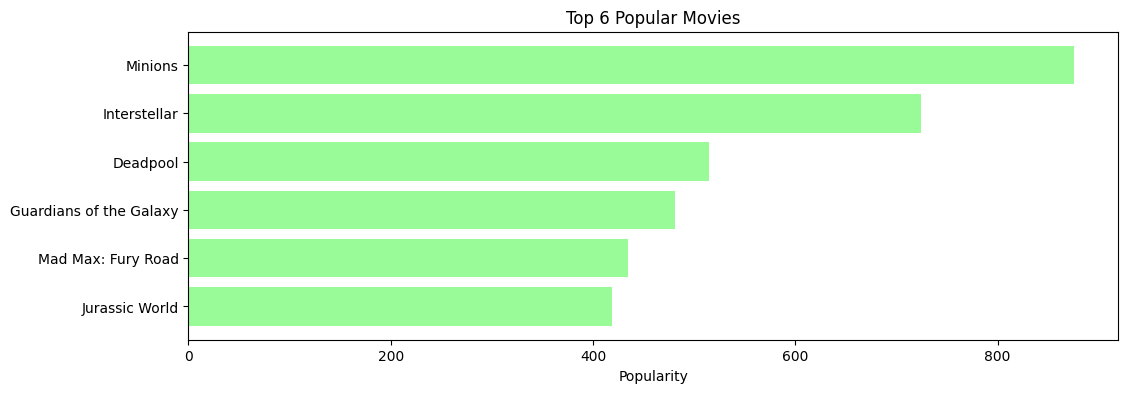

In [ ]:
pop= df5000Movie.sort_values('popularity', ascending=False)

plt.figure(figsize=(12,4))
plt.barh(pop['title'].head(6),pop['popularity'].head(6), align='center', color='palegreen')
plt.gca().invert_yaxis()
plt.xlabel("Popularity")
plt.title("Top 6 Popular Movies")

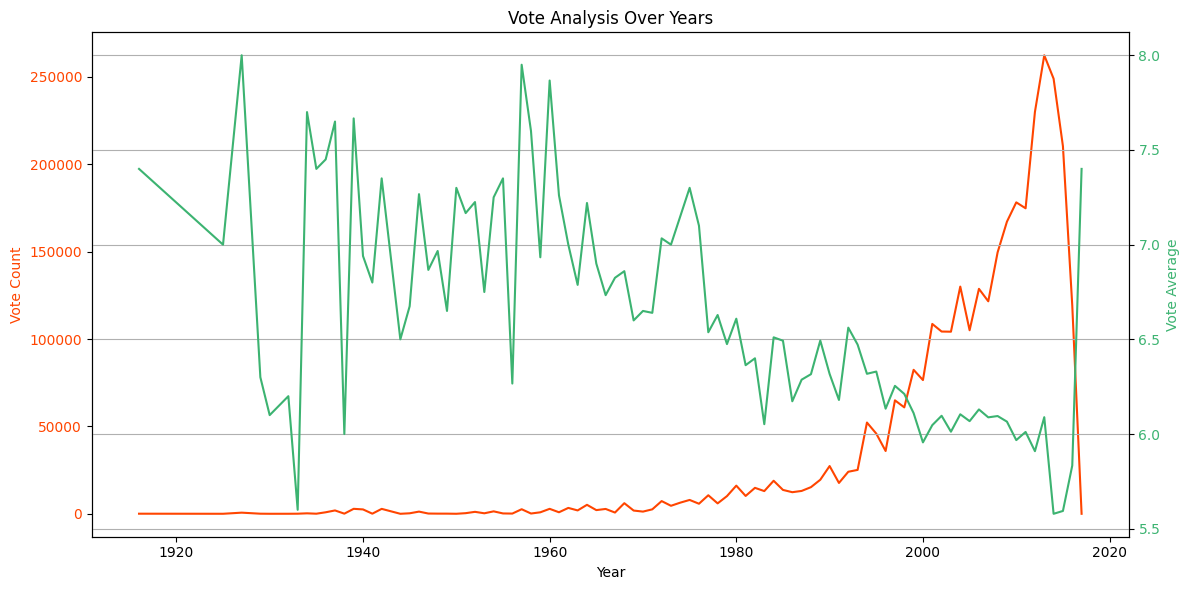

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'orangered'
ax1.set_xlabel('Year')
ax1.set_ylabel('Vote Count', color=color)
ax1.plot(total_vote_by_year.index, total_vote_by_year.values, label='Total Vote', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'mediumseagreen'
ax2.set_ylabel('Vote Average', color=color)
ax2.plot(average_vote_by_year.index, average_vote_by_year.values, label='Average Vote', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Vote Analysis Over Years')
fig.tight_layout()
plt.grid(True)
plt.show()

# **Data Pre-processing**

In [ ]:
columns_to_drop = ['budget', 'homepage', 'original_language', 'original_title',
                   'popularity', 'production_countries', 'revenue', 'runtime',
                   'spoken_languages', 'status']

df5000Movie.drop(columns=columns_to_drop, inplace=True)
df5000Movie.head()

,genres,id,keywords,overview,production_companies,release_date,tagline,title,vote_average,vote_count
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Enter the World of Pandora.,Avatar,7.2,11800
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,A Plan No One Escapes,Spectre,6.3,4466
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",Following the death of District Attorney Harve...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,The Legend Ends,The Dark Knight Rises,7.6,9106
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","John Carter is a war-weary, former military ca...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
df5000Movie = df5000Movie.set_index('id')
df5000MovieCredit = df5000MovieCredit.set_index('movie_id')

for index, row in df5000MovieCredit.iterrows():
    if index in df5000Movie.index:
        df5000Movie.loc[index, 'cast'] = row['cast']
        df5000Movie.loc[index, 'crew'] = row['crew']

df5000Movie.reset_index(inplace=True)
df5000Movie.head(5)

,id,genres,keywords,overview,production_companies,release_date,tagline,title,vote_average,vote_count,cast,crew
0,19995,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",Following the death of District Attorney Harve...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","John Carter is a war-weary, former military ca...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
features = ['genres', 'keywords', 'cast', 'crew']

def handle_nan_and_eval(x):
    if isinstance(x, list):
        return x
    elif pd.isna(x):
        return []
    else:
        return literal_eval(x)

df5000Movie[features] = df5000Movie[features].applymap(handle_nan_and_eval)

In [ ]:
def extract_names(genres_list):
    return ', '.join(genre['name'] for genre in genres_list)

df5000Movie['genres_extracted'] = df5000Movie['genres'].apply(extract_names)
df5000Movie.head(3)

,id,genres,keywords,overview,production_companies,release_date,tagline,title,vote_average,vote_count,cast,crew,genres_extracted
0,19995,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 1463, 'name': 'culture clash'}, {'id':...","In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Enter the World of Pandora.,Avatar,7.2,11800,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de...","Action, Adventure, Fantasy, Science Fiction"
1,285,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...","Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{'cast_id': 4, 'character': 'Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...","Adventure, Fantasy, Action"
2,206647,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,A Plan No One Escapes,Spectre,6.3,4466,"[{'cast_id': 1, 'character': 'James Bond', 'cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de...","Action, Adventure, Crime"


In [ ]:
df5000Movie['keywords_extracted'] = df5000Movie['keywords'].apply(extract_names)
df5000Movie.head(3)

,id,genres,keywords,overview,production_companies,release_date,tagline,title,vote_average,vote_count,cast,crew,genres_extracted,keywords_extracted
0,19995,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 1463, 'name': 'culture clash'}, {'id':...","In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Enter the World of Pandora.,Avatar,7.2,11800,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de...","Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony..."
1,285,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...","Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{'cast_id': 4, 'character': 'Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...","Adventure, Fantasy, Action","ocean, drug abuse, exotic island, east india t..."
2,206647,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,A Plan No One Escapes,Spectre,6.3,4466,"[{'cast_id': 1, 'character': 'James Bond', 'cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de...","Action, Adventure, Crime","spy, based on novel, secret agent, sequel, mi6..."


In [ ]:
def extract_director_name(crew_list):
    for person in crew_list:
        if person.get('job') == 'Director':
            return person.get('name')
    return None
df5000Movie['crew_extracted'] = df5000Movie['crew'].apply(extract_director_name)
df5000Movie.head()

,id,genres,keywords,overview,production_companies,release_date,tagline,title,vote_average,vote_count,cast,crew,genres_extracted,keywords_extracted,crew_extracted
0,19995,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 1463, 'name': 'culture clash'}, {'id':...","In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Enter the World of Pandora.,Avatar,7.2,11800,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de...","Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony...",James Cameron
1,285,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...","Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{'cast_id': 4, 'character': 'Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...","Adventure, Fantasy, Action","ocean, drug abuse, exotic island, east india t...",Gore Verbinski
2,206647,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,A Plan No One Escapes,Spectre,6.3,4466,"[{'cast_id': 1, 'character': 'James Bond', 'cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de...","Action, Adventure, Crime","spy, based on novel, secret agent, sequel, mi6...",Sam Mendes
3,49026,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...","[{'id': 849, 'name': 'dc comics'}, {'id': 853,...",Following the death of District Attorney Harve...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{'cast_id': 2, 'character': 'Bruce Wayne / Ba...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de...","Action, Crime, Drama, Thriller","dc comics, crime fighter, terrorist, secret id...",Christopher Nolan
4,49529,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 818, 'name': 'based on novel'}, {'id':...","John Carter is a war-weary, former military ca...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,"Lost in our world, found in another.",John Carter,6.1,2124,"[{'cast_id': 5, 'character': 'John Carter', 'c...","[{'credit_id': '52fe479ac3a36847f813eaa3', 'de...","Action, Adventure, Science Fiction","based on novel, mars, medallion, space travel,...",Andrew Stanton


In [ ]:
def extract_first_five_names(genres_list):
    names = [genre['name'] for genre in genres_list[:5]]
    return ', '.join(names)

df5000Movie['cast_extracted'] = df5000Movie['cast'].apply(extract_first_five_names)
df5000Movie.head()

,id,genres,keywords,overview,production_companies,release_date,tagline,title,vote_average,vote_count,cast,crew,genres_extracted,keywords_extracted,crew_extracted,cast_extracted
0,19995,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 1463, 'name': 'culture clash'}, {'id':...","In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Enter the World of Pandora.,Avatar,7.2,11800,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de...","Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony...",James Cameron,"Sam Worthington, Zoe Saldana, Sigourney Weaver..."
1,285,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...","Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{'cast_id': 4, 'character': 'Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...","Adventure, Fantasy, Action","ocean, drug abuse, exotic island, east india t...",Gore Verbinski,"Johnny Depp, Orlando Bloom, Keira Knightley, S..."
2,206647,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,A Plan No One Escapes,Spectre,6.3,4466,"[{'cast_id': 1, 'character': 'James Bond', 'cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de...","Action, Adventure, Crime","spy, based on novel, secret agent, sequel, mi6...",Sam Mendes,"Daniel Craig, Christoph Waltz, Léa Seydoux, Ra..."
3,49026,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...","[{'id': 849, 'name': 'dc comics'}, {'id': 853,...",Following the death of District Attorney Harve...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{'cast_id': 2, 'character': 'Bruce Wayne / Ba...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de...","Action, Crime, Drama, Thriller","dc comics, crime fighter, terrorist, secret id...",Christopher Nolan,"Christian Bale, Michael Caine, Gary Oldman, An..."
4,49529,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 818, 'name': 'based on novel'}, {'id':...","John Carter is a war-weary, former military ca...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,"Lost in our world, found in another.",John Carter,6.1,2124,"[{'cast_id': 5, 'character': 'John Carter', 'c...","[{'credit_id': '52fe479ac3a36847f813eaa3', 'de...","Action, Adventure, Science Fiction","based on novel, mars, medallion, space travel,...",Andrew Stanton,"Taylor Kitsch, Lynn Collins, Samantha Morton, ..."


In [ ]:
df5000Movie['content'] = df5000Movie['overview'] + ' ' +  df5000Movie['crew_extracted'] + ' ' + df5000Movie['cast_extracted'] + ' ' +df5000Movie['keywords_extracted'] + ' ' + df5000Movie['genres_extracted']
df5000Movie['content'] = df5000Movie['content'].str.lower()
df5000Movie.head(5)

,id,genres,keywords,overview,production_companies,release_date,tagline,title,vote_average,vote_count,cast,crew,genres_extracted,keywords_extracted,crew_extracted,cast_extracted,content
0,19995,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 1463, 'name': 'culture clash'}, {'id':...","In the 22nd century, a paraplegic Marine is di...","[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,Enter the World of Pandora.,Avatar,7.2,11800,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de...","Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony...",James Cameron,"Sam Worthington, Zoe Saldana, Sigourney Weaver...","in the 22nd century, a paraplegic marine is di..."
1,285,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...","Captain Barbossa, long believed to be dead, ha...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{'cast_id': 4, 'character': 'Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...","Adventure, Fantasy, Action","ocean, drug abuse, exotic island, east india t...",Gore Verbinski,"Johnny Depp, Orlando Bloom, Keira Knightley, S...","captain barbossa, long believed to be dead, ha..."
2,206647,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",A cryptic message from Bond’s past sends him o...,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,A Plan No One Escapes,Spectre,6.3,4466,"[{'cast_id': 1, 'character': 'James Bond', 'cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de...","Action, Adventure, Crime","spy, based on novel, secret agent, sequel, mi6...",Sam Mendes,"Daniel Craig, Christoph Waltz, Léa Seydoux, Ra...",a cryptic message from bond’s past sends him o...
3,49026,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...","[{'id': 849, 'name': 'dc comics'}, {'id': 853,...",Following the death of District Attorney Harve...,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{'cast_id': 2, 'character': 'Bruce Wayne / Ba...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de...","Action, Crime, Drama, Thriller","dc comics, crime fighter, terrorist, secret id...",Christopher Nolan,"Christian Bale, Michael Caine, Gary Oldman, An...",following the death of district attorney harve...
4,49529,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'id': 818, 'name': 'based on novel'}, {'id':...","John Carter is a war-weary, former military ca...","[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,"Lost in our world, found in another.",John Carter,6.1,2124,"[{'cast_id': 5, 'character': 'John Carter', 'c...","[{'credit_id': '52fe479ac3a36847f813eaa3', 'de...","Action, Adventure, Science Fiction","based on novel, mars, medallion, space travel,...",Andrew Stanton,"Taylor Kitsch, Lynn Collins, Samantha Morton, ...","john carter is a war-weary, former military ca..."


In [ ]:
dfUserRatingByMovie = dfRatings.pivot_table(index='userId', columns='movieId', values='rating', aggfunc='first')
dfUserRatingByMovie = dfUserRatingByMovie.reset_index().rename_axis(None, axis=1)
dfUserRatingByMovie.shape

(3180, 12766)

# **Feature Extraction**

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')
df5000Movie['content'] = df5000Movie['content'].fillna('')
content_matrix = tfidf.fit_transform(df5000Movie['content'])
dfContent = pd.DataFrame(content_matrix.toarray(), columns=tfidf.get_feature_names_out())
dfContent.head(5)

,00,000,007,07am,10,100,1000,101,108,10th,...,škofić,špela,γη,снигирь,юлия,معادی,پیمان,卧底肥妈,绝地奶霸,超级妈妈
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Item Clustering**

In [ ]:
def userClusterCosine(X, k, max_iters):
    X.reset_index(drop=True, inplace=True)

    centroids = X.iloc[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
        labels = np.argmax(similarities, axis=1)

        new_centroids = []

        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centroid = np.mean(cluster_points, axis=0)
                new_centroids.append(new_centroid)
            else:
                new_centroids.append(X.iloc[np.random.choice(X.shape[0], 1)].values[0])

        new_centroids = np.array(new_centroids)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, labels

In [ ]:
dfSilhoutteCosineItem = dfContent.fillna(0)

In [ ]:
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for i in range(3, 10):
    centroids_, labels_ = userClusterCosine(dfSilhoutteCosineItem, i, 100)

    silhouette = silhouette_score(dfSilhoutteCosineItem, labels_)
    davies_bouldin = davies_bouldin_score(dfSilhoutteCosineItem, labels_)
    calinski_harabasz = calinski_harabasz_score(dfSilhoutteCosineItem, labels_)

    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_harabasz_scores.append(calinski_harabasz)


<ipython-input-20-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-20-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-20-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-20-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-20-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxi

   Number of Clusters (i)  Silhouette Score  Davies-Bouldin Score  \
0                       3         -0.000230             18.483607   
1                       4         -0.000723             19.256243   
2                       5         -0.001828             18.297931   
3                       6         -0.010204             16.681259   
4                       7         -0.009110             16.129481   
5                       8         -0.008278             16.097598   
6                       9         -0.016292             15.491822   

   Calinski-Harabasz Score  
0                 9.421198  
1                 8.040153  
2                 7.261254  
3                 7.220759  
4                 6.741322  
5                 6.282427  
6                 5.894414  


In [ ]:
df_scores = pd.DataFrame({
    'Number of Clusters (i)': range(3, 10),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Score': davies_bouldin_scores,
    'Calinski-Harabasz Score': calinski_harabasz_scores
})

print(df_scores)

In [ ]:
itemCentroids, itemLabels = userClusterCosine(dfContent, 6, 100)

unique_values, counts = np.unique(itemLabels, return_counts=True)
for i in range(len(unique_values)):
    print(f"Cluster {unique_values[i]}: {counts[i]}")

<ipython-input-20-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))


Cluster 0: 815
Cluster 1: 710
Cluster 2: 525
Cluster 3: 669
Cluster 4: 1053
Cluster 5: 1031


# **User Clustering**

In [ ]:
dfSilhoutteCosineUser = dfUserRatingByMovie.fillna(0)

In [ ]:
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for i in range(3, 10):
    centroids_, labels_ = userClusterCosine(dfSilhoutteCosineUser, i, 1000)

    silhouette = silhouette_score(dfSilhoutteCosineUser, labels_)
    davies_bouldin = davies_bouldin_score(dfSilhoutteCosineUser, labels_)
    calinski_harabasz = calinski_harabasz_score(dfSilhoutteCosineUser, labels_)

    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    calinski_harabasz_scores.append(calinski_harabasz)

In [ ]:
df_scores = pd.DataFrame({
    'Number of Clusters (i)': range(3, 10),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Score': davies_bouldin_scores,
    'Calinski-Harabasz Score': calinski_harabasz_scores
})

print(df_scores)

   Number of Clusters (i)  Silhouette Score  Davies-Bouldin Score  \
0                       3          0.069567              1.028970   
1                       4          0.020253              1.344073   
2                       5         -0.038877              1.702702   
3                       6          0.075315              1.728540   
4                       7         -0.115275              3.895887   
5                       8         -0.129026              5.309637   
6                       9         -0.106373              3.961264   

   Calinski-Harabasz Score  
0               397.453293  
1               283.101099  
2               220.089685  
3               138.231102  
4               160.465596  
5               133.240128  
6               117.220874  


In [ ]:
dfFilledNull = dfUserRatingByMovie.fillna(0)

# **Predict User-Item**

In [ ]:
def fillSparsityMeans(clusterID, userLabels, dfUserRatingByMovie):
    columns_to_keep = dfUserRatingByMovie.columns[dfUserRatingByMovie.columns.isin(df5000Movie['id'])]
    dfUserCluster = dfUserRatingByMovie[columns_to_keep].copy()
    dfUserCluster['cluster'] = userLabels
    dfFill = dfUserCluster[dfUserCluster['cluster'] == clusterID]
    dfFill = dfFill.drop(columns=['cluster'])

    numeric_cols = dfFill.select_dtypes(include='number').columns
    for col in numeric_cols:
        filtered_values = dfFill[col][(dfFill[col].notnull()) & (dfFill[col] != 0)]
        mean_value = filtered_values.mean()
        dfFill[col].fillna(mean_value, inplace=True)
        dfFill[col].replace(0, mean_value, inplace=True)

    dfFill = dfFill.fillna(0)
    return dfFill

In [ ]:
def fillSparsityMedian(clusterID, userLabels, dfUserRatingByMovie):

    columns_to_keep = dfUserRatingByMovie.columns[dfUserRatingByMovie.columns.isin(df5000Movie['id'])]
    dfUserCluster = dfUserRatingByMovie[columns_to_keep].copy()
    dfUserCluster['cluster'] = userLabels
    dfFill = dfUserCluster[dfUserCluster['cluster'] == clusterID]
    dfFill = dfFill.drop(columns=['cluster'])

    numeric_cols = dfFill.select_dtypes(include='number').columns
    for col in numeric_cols:
        filtered_values = dfFill[col][(dfFill[col].notnull()) & (dfFill[col] != 0)]
        median_value = filtered_values.median()
        dfFill[col].fillna(median_value, inplace=True)
        dfFill[col].replace(0, median_value, inplace=True)

    dfFill = dfFill.fillna(0)
    return dfFill

In [ ]:
def fillSparsityMode(clusterID, userLabels, dfUserRatingByMovie):

    columns_to_keep = dfUserRatingByMovie.columns[dfUserRatingByMovie.columns.isin(df5000Movie['id'])]
    dfUserCluster = dfUserRatingByMovie[columns_to_keep].copy()
    dfUserCluster['cluster'] = userLabels
    dfFill = dfUserCluster[dfUserCluster['cluster'] == clusterID].drop(columns=['cluster'])

    for col in dfFill.select_dtypes(include='number').columns:
        filtered_values = dfFill[col][(dfFill[col].notnull()) & (dfFill[col] != 0)]
        mode_value = filtered_values.mode().iloc[0] if not filtered_values.empty else None
        mean_value = filtered_values.mean() if not filtered_values.empty else None

        fill_value = mode_value if pd.notnull(mode_value) else mean_value
        fill_value = fill_value if fill_value is not None else 0

        dfFill[col].fillna(fill_value, inplace=True)
        dfFill[col].replace(0, fill_value, inplace=True)

    dfFill.fillna(0)

    return dfFill

In [ ]:
def cal_cosine_similarity(row, target_row):
    dot_product = np.dot(row, target_row)
    norm_product = norm(row) * norm(target_row)
    similarity = dot_product / norm_product
    return similarity

In [ ]:
def getSimilarList(clusterID,itemLabels):
    dfItemCluster = dfContent.copy()
    dfItemCluster['cluster'] = itemLabels
    dfItemCluster = dfItemCluster[dfItemCluster['cluster'] == clusterID]
    dfItemCluster = dfItemCluster.drop(columns=['cluster'])
    return dfItemCluster

In [ ]:
# movie_indices = pd.Series(dfContent.index, index=dfContent['id']).drop_duplicates()
user_indices = pd.Series(dfUserRatingByMovie.index, index=dfUserRatingByMovie['userId']).drop_duplicates()

In [ ]:
def userItemPredictMeans(user, item):
    targetPredict  = 0
    idx = df5000Movie[df5000Movie['id'] == item].index[0]
    # idx = movie_indices.loc[item]

    idxuser = user_indices.loc[user]
    userClusterName = userLabels[idxuser]
    itemCluster = itemLabels[idx]
    dfFilled = cluster_filled_user_mean_dataframes.get(userClusterName)
    dfItemCluster = cluster_similar_item_dataframes.get(itemCluster)

    target_row = dfItemCluster.loc[idx]
    total_weight = 0
    total_predict = 0

    for index, row in dfItemCluster.iterrows():
        if index == idx:
            continue
        abc = df5000Movie.loc[index,'id']
        # abc = movie_indices[movie_indices == index].index[0]
        if abc in dfFilled.columns:
            cosine_sim = cal_cosine_similarity(row, target_row)
            # if cosine_sim.isnull():
            #     continue
            weight = cosine_sim
            rating = dfFilled.loc[idxuser, abc]
            if not pd.isnull(rating) and rating != 0:
                total_weight += weight
                total_predict += weight * rating
        else:
            continue
    targetPredict = total_predict / total_weight
    return targetPredict

In [ ]:
def userItemPredictMedian(user, item):
    targetPredict  = 0
    idx = df5000Movie[df5000Movie['id'] == item].index[0]
    # idx = movie_indices.loc[item]
    idxuser = user_indices.loc[user]
    userClusterName = userLabels[idxuser]

    itemCluster = itemLabels[idx]

    dfFilled = cluster_filled_user_med_dataframes.get(userClusterName)
    dfItemCluster = cluster_similar_item_dataframes.get(itemCluster)

    target_row = dfItemCluster.loc[idx]
    total_weight = 0
    total_predict = 0

    for index, row in dfItemCluster.iterrows():
        if index == idx:
            continue
        abc = df5000Movie.loc[index,'id']
        # abc = movie_indices[movie_indices == index].index[0]
        if abc in dfFilled.columns:
            cosine_sim = cal_cosine_similarity(row, target_row)
            # if cosine_sim.isnull():
            #     continue
            weight = cosine_sim
            rating = dfFilled.loc[idxuser, abc]
            if not pd.isnull(rating):
                total_weight += weight
                total_predict += weight * rating
        else:
            continue
    targetPredict = total_predict / total_weight
    return targetPredict

In [ ]:
def userItemPredictMode(user, item):
    targetPredict  = 0
    idx = df5000Movie[df5000Movie['id'] == item].index[0]

    # idx = movie_indices.loc[item]
    idxuser = user_indices.loc[user]
    userClusterName = userLabels[idxuser]

    itemCluster = itemLabels[idx]

    dfFilled = cluster_filled_user_mode_dataframes.get(userClusterName)
    dfItemCluster = cluster_similar_item_dataframes.get(itemCluster)

    target_row = dfItemCluster.loc[idx]
    total_weight = 0
    total_predict = 0

    for index, row in dfItemCluster.iterrows():
        if index == idx:
            continue
        abc = df5000Movie.loc[index,'id']
        # abc = movie_indices[movie_indices == index].index[0]
        if abc in dfFilled.columns:
            cosine_sim = cal_cosine_similarity(row, target_row)
            # if cosine_sim.isnull():
            #     continue
            weight = cosine_sim
            rating = dfFilled.loc[idxuser, abc]
            if not pd.isnull(rating):
                total_weight += weight
                total_predict += weight * rating
        else:
            continue
    targetPredict = total_predict / total_weight
    return targetPredict

In [ ]:
def userItemPredict(user, item, cluster_filled_user_mode_dataframes, cluster_similar_item_dataframes):
    targetPredict  = 0
    idx = df5000Movie[df5000Movie['id'] == item].index[0]

    # idx = movie_indices.loc[item]
    idxuser = user_indices.loc[user]
    userClusterName = userLabels[idxuser]

    itemCluster = itemLabels[idx]

    dfFilled = cluster_filled_user_mode_dataframes.get(userClusterName)
    dfItemCluster = cluster_similar_item_dataframes.get(itemCluster)

    target_row = dfItemCluster.loc[idx]
    total_weight = 0
    total_predict = 0

    for index, row in dfItemCluster.iterrows():
        if index == idx:
            continue
        abc = df5000Movie.loc[index,'id']
        # abc = movie_indices[movie_indices == index].index[0]
        if abc in dfFilled.columns:
            cosine_sim = cal_cosine_similarity(row, target_row)
            # if cosine_sim.isnull():
            #     continue
            weight = cosine_sim
            rating = dfFilled.loc[idxuser, abc]
            if not pd.isnull(rating):
                total_weight += weight
                total_predict += weight * rating
        else:
            continue
    targetPredict = total_predict / total_weight
    return targetPredict

# **Evaluation**

In [ ]:
dfRatingSelection = dfRatings[['userId', 'movieId', 'rating']].copy()
dfTestSelection = dfRatingSelection[dfRatingSelection['movieId'].isin(df5000Movie['id'])]
dfTestSelection = dfTestSelection.sample(n=50, random_state=42)
dfTestSelection.shape

(50, 3)

In [ ]:
def calculate_errors(df):
    # Calculate squared errors
    df['error_mean_squared'] = (df['predictMean'] - df['rating']) ** 2
    df['error_median_squared'] = (df['predictMedian'] - df['rating']) ** 2
    df['error_mode_squared'] = (df['predictMode'] - df['rating']) ** 2

    # Calculate absolute errors
    df['error_mean_absolute'] = np.abs(df['predictMean'] - df['rating'])
    df['error_median_absolute'] = np.abs(df['predictMedian'] - df['rating'])
    df['error_mode_absolute'] = np.abs(df['predictMode'] - df['rating'])

    # Calculate MSE, RMSE, and MAE
    mse_mean = df['error_mean_squared'].mean()
    mse_median = df['error_median_squared'].mean()
    mse_mode = df['error_mode_squared'].mean()
    rmse_mean = np.sqrt(mse_mean)
    rmse_median = np.sqrt(mse_median)
    rmse_mode = np.sqrt(mse_mode)
    mae_mean = df['error_mean_absolute'].mean()
    mae_median = df['error_median_absolute'].mean()
    mae_mode = df['error_mode_absolute'].mean()

    return mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode

# Example usage:

## User: 3 - Item:4

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 3, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 4, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2}

dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2}

dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)

cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.4076635628580478
Mean Squared Error (MSE) - predictMedian: 1.7391930042256256
Mean Squared Error (MSE) - predictMode: 1.8351184568399308
Root Mean Squared Error (RMSE) - predictMean: 1.18644998329388
Root Mean Squared Error (RMSE) - predictMedian: 1.3187846693928564
Root Mean Squared Error (RMSE) - predictMode: 1.3546654409262573
Mean Absolute Error (MAE) - predictMean: 0.9854191605223583
Mean Absolute Error (MAE) - predictMedian: 1.0918378473334587
Mean Absolute Error (MAE) - predictMode: 1.1197512603458328


## User: 3 - Item: 5

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 3, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 5, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2}

dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2}

dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)
dfSimItemCluster4 = getSimilarList(4, itemLabels)

cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3, 4:dfSimItemCluster4}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.4934979484128874
Mean Squared Error (MSE) - predictMedian: 2.013417370921513
Mean Squared Error (MSE) - predictMode: 2.2184672334867224
Root Mean Squared Error (RMSE) - predictMean: 1.2220875371318076
Root Mean Squared Error (RMSE) - predictMedian: 1.418949389837958
Root Mean Squared Error (RMSE) - predictMode: 1.4894519909976025
Mean Absolute Error (MAE) - predictMean: 1.0236044923533816
Mean Absolute Error (MAE) - predictMedian: 1.2639950117317327
Mean Absolute Error (MAE) - predictMode: 1.3321063729696552


## User: 3 - Item: 6

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 3, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 6, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2}

dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2}

dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)
dfSimItemCluster4 = getSimilarList(4, itemLabels)
dfSimItemCluster5 = getSimilarList(5, itemLabels)


cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3, 4:dfSimItemCluster4, 5:dfSimItemCluster5}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.332294552951438
Mean Squared Error (MSE) - predictMedian: 1.8935311739208505
Mean Squared Error (MSE) - predictMode: 2.064407963707514
Root Mean Squared Error (RMSE) - predictMean: 1.1542506456361366
Root Mean Squared Error (RMSE) - predictMedian: 1.3760563847171563
Root Mean Squared Error (RMSE) - predictMode: 1.4368047757811475
Mean Absolute Error (MAE) - predictMean: 0.9537449229383075
Mean Absolute Error (MAE) - predictMedian: 1.1577618209102922
Mean Absolute Error (MAE) - predictMode: 1.2073538972340174


## User 4 - Item: 4

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 4, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 4, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster3 = fillSparsityMeans(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2, 3: dfFilledMeanUserCluster3}

dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster3 = fillSparsityMedian(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2, 3: dfFilledMedUserCluster3}

dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster3 = fillSparsityMode(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2, 3: dfFilledModeUserCluster3}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)

cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.3639272759302032
Mean Squared Error (MSE) - predictMedian: 1.7856332168147622
Mean Squared Error (MSE) - predictMode: 1.9612174813662966
Root Mean Squared Error (RMSE) - predictMean: 1.1678729708021345
Root Mean Squared Error (RMSE) - predictMedian: 1.336275876013169
Root Mean Squared Error (RMSE) - predictMode: 1.4004347472718237
Mean Absolute Error (MAE) - predictMean: 0.9688220246563147
Mean Absolute Error (MAE) - predictMedian: 1.1458608909707062
Mean Absolute Error (MAE) - predictMode: 1.2011215704932101


## User: 4 - Item: 5

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 4, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 5, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster3 = fillSparsityMeans(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2, 3: dfFilledMeanUserCluster3}

dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster3 = fillSparsityMedian(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2, 3: dfFilledMedUserCluster3}

dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster3 = fillSparsityMode(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2, 3: dfFilledModeUserCluster3}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)
dfSimItemCluster4 = getSimilarList(4, itemLabels)


cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3, 4:dfSimItemCluster4}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.4540812571437418
Mean Squared Error (MSE) - predictMedian: 1.8053986283006271
Mean Squared Error (MSE) - predictMode: 1.941037966336371
Root Mean Squared Error (RMSE) - predictMean: 1.2058529168782326
Root Mean Squared Error (RMSE) - predictMedian: 1.343651230156333
Root Mean Squared Error (RMSE) - predictMode: 1.3932113860919926
Mean Absolute Error (MAE) - predictMean: 1.0021990789638822
Mean Absolute Error (MAE) - predictMedian: 1.1521178153687643
Mean Absolute Error (MAE) - predictMode: 1.219616290439649


## User: 4 - Item: 6

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 4, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 6, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster3 = fillSparsityMeans(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2, 3: dfFilledMeanUserCluster3}

dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster3 = fillSparsityMedian(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2, 3: dfFilledMedUserCluster3}

dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster3 = fillSparsityMode(3, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2, 3: dfFilledModeUserCluster3}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)
dfSimItemCluster4 = getSimilarList(4, itemLabels)
dfSimItemCluster5 = getSimilarList(5, itemLabels)


cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3, 4:dfSimItemCluster4, 5:dfSimItemCluster5}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.4404978146412408
Mean Squared Error (MSE) - predictMedian: 2.069284946145368
Mean Squared Error (MSE) - predictMode: 2.2163821469546754
Root Mean Squared Error (RMSE) - predictMean: 1.2002074048435298
Root Mean Squared Error (RMSE) - predictMedian: 1.438500937137466
Root Mean Squared Error (RMSE) - predictMode: 1.4887518755503468
Mean Absolute Error (MAE) - predictMean: 0.994308674472301
Mean Absolute Error (MAE) - predictMedian: 1.233874860979222
Mean Absolute Error (MAE) - predictMode: 1.2976179492511963


## User: 6 - Item: 4

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 6, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 4, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster3 = fillSparsityMeans(3, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster4 = fillSparsityMeans(4, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster5 = fillSparsityMeans(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2, 3: dfFilledMeanUserCluster3, 4: dfFilledMeanUserCluster4, 5: dfFilledMeanUserCluster5}


dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster3 = fillSparsityMedian(3, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster4 = fillSparsityMedian(4, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster5 = fillSparsityMedian(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2, 3: dfFilledMedUserCluster3, 4: dfFilledMedUserCluster4, 5: dfFilledMedUserCluster5}


dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster3 = fillSparsityMode(3, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster4 = fillSparsityMode(4, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster5 = fillSparsityMode(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2, 3: dfFilledModeUserCluster3, 4: dfFilledModeUserCluster4, 5: dfFilledModeUserCluster5}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)


cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.403494140839181
Mean Squared Error (MSE) - predictMedian: 3.0201994160313395
Mean Squared Error (MSE) - predictMode: 3.2479657504139503
Root Mean Squared Error (RMSE) - predictMean: 1.1846915804711289
Root Mean Squared Error (RMSE) - predictMedian: 1.737872094266819
Root Mean Squared Error (RMSE) - predictMode: 1.8022113500957513
Mean Absolute Error (MAE) - predictMean: 0.9736480646724095
Mean Absolute Error (MAE) - predictMedian: 1.4978498242051212
Mean Absolute Error (MAE) - predictMode: 1.5689779927395542


## User: 6 - Item: 5

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 6, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 5, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster3 = fillSparsityMeans(3, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster4 = fillSparsityMeans(4, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster5 = fillSparsityMeans(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2, 3: dfFilledMeanUserCluster3, 4: dfFilledMeanUserCluster4, 5: dfFilledMeanUserCluster5}


dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster3 = fillSparsityMedian(3, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster4 = fillSparsityMedian(4, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster5 = fillSparsityMedian(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2, 3: dfFilledMedUserCluster3, 4: dfFilledMedUserCluster4, 5: dfFilledMedUserCluster5}


dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster3 = fillSparsityMode(3, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster4 = fillSparsityMode(4, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster5 = fillSparsityMode(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2, 3: dfFilledModeUserCluster3, 4: dfFilledModeUserCluster4, 5: dfFilledModeUserCluster5}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)
dfSimItemCluster4 = getSimilarList(4, itemLabels)

cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3, 4:dfSimItemCluster4}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.2660151707334601
Mean Squared Error (MSE) - predictMedian: 2.2557752315366595
Mean Squared Error (MSE) - predictMode: 2.453818845141132
Root Mean Squared Error (RMSE) - predictMean: 1.1251733958521506
Root Mean Squared Error (RMSE) - predictMedian: 1.501923843454341
Root Mean Squared Error (RMSE) - predictMode: 1.5664669945904164
Mean Absolute Error (MAE) - predictMean: 0.9317718025098379
Mean Absolute Error (MAE) - predictMedian: 1.2811862258817728
Mean Absolute Error (MAE) - predictMode: 1.3548385450544542


## User: 6 - Item: 6

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 6, 100)
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 6, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster3 = fillSparsityMeans(3, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster4 = fillSparsityMeans(4, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster5 = fillSparsityMeans(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2, 3: dfFilledMeanUserCluster3, 4: dfFilledMeanUserCluster4, 5: dfFilledMeanUserCluster5}


dfFilledMedUserCluster0 = fillSparsityMedian(0, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster1 = fillSparsityMedian(1, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster2 = fillSparsityMedian(2, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster3 = fillSparsityMedian(3, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster4 = fillSparsityMedian(4, userLabels, dfUserRatingByMovie)

dfFilledMedUserCluster5 = fillSparsityMedian(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_med_dataframes = {0: dfFilledMedUserCluster0, 1: dfFilledMedUserCluster1, 2: dfFilledMedUserCluster2, 3: dfFilledMedUserCluster3, 4: dfFilledMedUserCluster4, 5: dfFilledMedUserCluster5}


dfFilledModeUserCluster0 = fillSparsityMode(0, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster1 = fillSparsityMode(1, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster2 = fillSparsityMode(2, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster3 = fillSparsityMode(3, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster4 = fillSparsityMode(4, userLabels, dfUserRatingByMovie)

dfFilledModeUserCluster5 = fillSparsityMode(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_mode_dataframes = {0: dfFilledModeUserCluster0, 1: dfFilledModeUserCluster1, 2: dfFilledModeUserCluster2, 3: dfFilledModeUserCluster3, 4: dfFilledModeUserCluster4, 5: dfFilledModeUserCluster5}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)
dfSimItemCluster4 = getSimilarList(4, itemLabels)
dfSimItemCluster5 = getSimilarList(5, itemLabels)


cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3, 4:dfSimItemCluster4, 5:dfSimItemCluster5}

dfTestSelection['predictMean'] = dfTestSelection.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMedian'] = dfTestSelection.apply(lambda row: userItemPredictMedian(row['userId'], row['movieId']), axis=1)
dfTestSelection['predictMode'] = dfTestSelection.apply(lambda row: userItemPredictMode(row['userId'], row['movieId']), axis=1)

mse_mean, mse_median, mse_mode, rmse_mean, rmse_median, rmse_mode, mae_mean, mae_median, mae_mode = calculate_errors(dfTestSelection)
print("Mean Squared Error (MSE) - predictMean:", mse_mean)
print("Mean Squared Error (MSE) - predictMedian:", mse_median)
print("Mean Squared Error (MSE) - predictMode:", mse_mode)

print("Root Mean Squared Error (RMSE) - predictMean:", rmse_mean)
print("Root Mean Squared Error (RMSE) - predictMedian:", rmse_median)
print("Root Mean Squared Error (RMSE) - predictMode:", rmse_mode)

print("Mean Absolute Error (MAE) - predictMean:", mae_mean)
print("Mean Absolute Error (MAE) - predictMedian:", mae_median)
print("Mean Absolute Error (MAE) - predictMode:", mae_mode)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))
<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


Mean Squared Error (MSE) - predictMean: 1.410952679107504
Mean Squared Error (MSE) - predictMedian: 2.3770530639337837
Mean Squared Error (MSE) - predictMode: 2.611189389114596
Root Mean Squared Error (RMSE) - predictMean: 1.187835291236754
Root Mean Squared Error (RMSE) - predictMedian: 1.541769458749843
Root Mean Squared Error (RMSE) - predictMode: 1.6159175069026872
Mean Absolute Error (MAE) - predictMean: 0.994435555330002
Mean Absolute Error (MAE) - predictMedian: 1.3514341545611854
Mean Absolute Error (MAE) - predictMode: 1.4251086188088793


#**Recommender**

In [ ]:
userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 6, 100)

In [ ]:
unique_values, counts = np.unique(userLabels, return_counts=True)

df = pd.DataFrame({'Value': unique_values, 'Count': counts})

print(df)

   Value  Count
0      0     82
1      1     27
2      2    115
3      3    491
4      4      4
5      5   2461


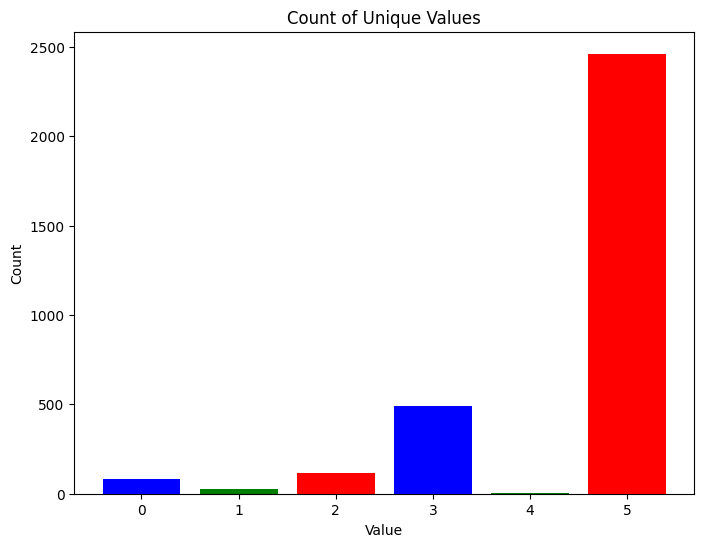

In [ ]:
plt.figure(figsize=(8, 6))
plt.bar(df['Value'], df['Count'], color=['blue', 'green', 'red'])  # You can set colors as per your preference
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Count of Unique Values')
plt.show()

In [ ]:
itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 5, 100)

<ipython-input-16-af7499834399>:7: RuntimeWarning: invalid value encountered in divide
  similarities = np.dot(X, centroids.T) / (np.linalg.norm(X, axis=1)[:, np.newaxis] * np.linalg.norm(centroids, axis=1))


In [ ]:
unique_values, counts = np.unique(itemLabels, return_counts=True)

df = pd.DataFrame({'Value': unique_values, 'Count': counts})

print(df)

   Value  Count
0      0    521
1      1    999
2      2   1349
3      3   1030
4      4    904


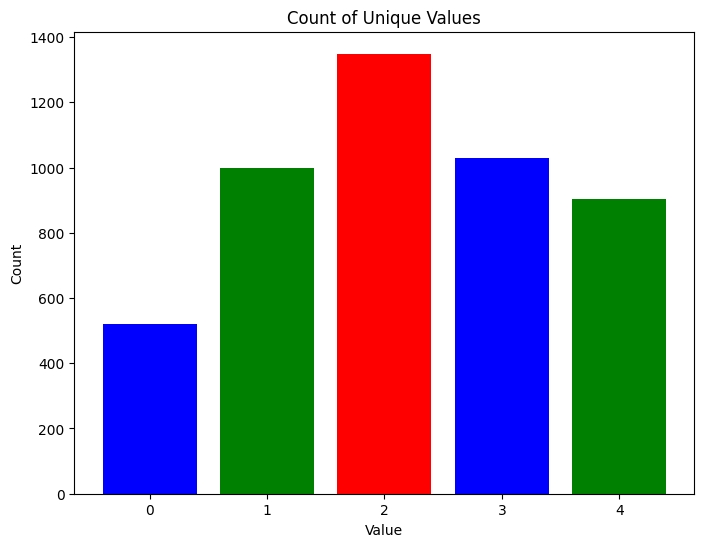

In [ ]:
plt.figure(figsize=(8, 6))
plt.bar(df['Value'], df['Count'], color=['blue', 'green', 'red'])  # You can set colors as per your preference
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('Count of Unique Values')
plt.show()

In [ ]:
dfItemResult = df5000Movie[['id', 'title']]
dfItemResult['cluster'] = itemLabels
print(dfItemResult[dfItemResult['cluster'] == 0])

          id                                              title  cluster
17      1865        Pirates of the Caribbean: On Stranger Tides        0
19    122917          The Hobbit: The Battle of the Five Armies        0
22     57158                The Hobbit: The Desolation of Smaug        0
26    271110                         Captain America: Civil War        0
31     68721                                         Iron Man 3        0
...      ...                                                ...      ...
4685  126141                       The Case of the Grinning Cat        0
4716   38786  The Blood of My Brother: A Story of Death in Iraq        0
4719   40652                                  The Married Woman        0
4720  339408                              The Birth of a Nation        0
4737   64973              Peace, Propaganda & the Promised Land        0

[521 rows x 3 columns]


<ipython-input-51-e39346037b5e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfItemResult['cluster'] = itemLabels


In [ ]:
random_user_id = np.random.choice(dfRatings['userId'])
voted_movie_ids = dfRatings.loc[dfRatings['userId'] == random_user_id, 'movieId'].values
new_movie_ids = df5000Movie.loc[~df5000Movie['id'].isin(voted_movie_ids), 'id']

new_df = pd.DataFrame({'userId': [random_user_id] * len(new_movie_ids), 'movieId': new_movie_ids})

print(new_df)

      userId  movieId
0       1013    19995
1       1013      285
2       1013   206647
3       1013    49026
4       1013    49529
...      ...      ...
4798    1013     9367
4799    1013    72766
4800    1013   231617
4801    1013   126186
4802    1013    25975

[4796 rows x 2 columns]


In [ ]:
# userCentroids, userLabels = userClusterCosine(dfSilhoutteCosineUser, 6, 100)
# itemCentroids, itemLabels = userClusterCosine(dfSilhoutteCosineItem, 5, 100)

dfFilledMeanUserCluster0 = fillSparsityMeans(0, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster1 = fillSparsityMeans(1, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster2 = fillSparsityMeans(2, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster3 = fillSparsityMeans(3, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster4 = fillSparsityMeans(4, userLabels, dfUserRatingByMovie)

dfFilledMeanUserCluster5 = fillSparsityMeans(5, userLabels, dfUserRatingByMovie)

cluster_filled_user_mean_dataframes = {0: dfFilledMeanUserCluster0, 1: dfFilledMeanUserCluster1, 2: dfFilledMeanUserCluster2, 3: dfFilledMeanUserCluster3, 4: dfFilledMeanUserCluster4, 5: dfFilledMeanUserCluster5}

dfSimItemCluster0 = getSimilarList(0, itemLabels)
dfSimItemCluster1 = getSimilarList(1, itemLabels)
dfSimItemCluster2 = getSimilarList(2, itemLabels)
dfSimItemCluster3 = getSimilarList(3, itemLabels)
dfSimItemCluster4 = getSimilarList(4, itemLabels)

cluster_similar_item_dataframes = {0: dfSimItemCluster0, 1: dfSimItemCluster1, 2: dfSimItemCluster2, 3:dfSimItemCluster3, 4:dfSimItemCluster4}

new_df['predictMean'] = new_df.apply(lambda row: userItemPredictMeans(row['userId'], row['movieId']), axis=1)
new_df.head(10)

<ipython-input-25-e3a038c7878b>:4: RuntimeWarning: invalid value encountered in scalar divide
  similarity = dot_product / norm_product


,userId,movieId,predictMean
0,1013,19995,3.306171
1,1013,285,3.350635
2,1013,206647,3.321659
3,1013,49026,3.341436
4,1013,49529,3.305686
5,1013,559,3.239982
6,1013,38757,3.231290
7,1013,99861,3.278077
8,1013,767,3.197404
9,1013,209112,3.306914


In [ ]:
sorted_new_df = new_df.sort_values(by='predictMean', ascending=False)
sorted_new_df = sorted_new_df.merge(df5000Movie[['id', 'title']], left_on='movieId', right_on='id', how='left')

sorted_new_df.drop(columns=['id'], inplace=True)

print(sorted_new_df)


      userId  movieId  predictMean  \
0       1013    66607     3.749180   
1       1013    10156     3.724250   
2       1013   251471     3.669619   
3       1013    13362     3.663203   
4       1013    18254     3.658630   
...      ...      ...          ...   
4791    1013   325123          NaN   
4792    1013   320435          NaN   
4793    1013    40963          NaN   
4794    1013   194588          NaN   
4795    1013    38786          NaN   

                                                  title  
0                                  Saving Private Perez  
1                          History of the World: Part I  
2                                  A LEGO Brickumentary  
3                                 Taxi to the Dark Side  
4                                                  Reds  
...                                                 ...  
4791                                    Teeth and Blood  
4792                                          UnDivided  
4793                 

In [ ]:
sorted_new_df.head(10)

,userId,movieId,predictMean,title
0,1013,66607,3.749180,Saving Private Perez
1,1013,10156,3.724250,History of the World: Part I
2,1013,251471,3.669619,A LEGO Brickumentary
3,1013,13362,3.663203,Taxi to the Dark Side
4,1013,18254,3.658630,Reds
5,1013,331745,3.656111,Top Spin
6,1013,2662,3.651867,House of 1000 Corpses
7,1013,10741,3.649089,Bobby
8,1013,253450,3.648485,The Assassin
9,1013,259943,3.638527,Coming Home


In [ ]:
rows_with_user_1013 = dfRatings[dfRatings['userId'] == 1013]
rows_with_user_1013 = rows_with_user_1013.sort_values(by='rating', ascending=False)
rows_with_user_1013 = rows_with_user_1013.merge(df5000Movie[['id', 'title']], left_on='movieId', right_on='id', how='left')
rows_with_user_1013 = rows_with_user_1013.drop(columns=['timestamp'])

print(rows_with_user_1013)

    userId  movieId  rating      id                               title
0     1013     2959     5.0  2959.0                      License to Wed
1     1013      318     4.5     NaN                                 NaN
2     1013     4226     4.5     NaN                                 NaN
3     1013     2329     4.5     NaN                                 NaN
4     1013     4011     4.0  4011.0                         Beetlejuice
5     1013     2672     4.0     NaN                                 NaN
6     1013    47610     4.0     NaN                                 NaN
7     1013    47200     4.0     NaN                                 NaN
8     1013    44195     4.0     NaN                                 NaN
9     1013    33794     4.0     NaN                                 NaN
10    1013       50     4.0     NaN                                 NaN
11    1013    49272     4.0     NaN                                 NaN
12    1013      110     4.0     NaN                             

In [ ]:
index_film_01 = df5000Movie[df5000Movie['id'] == 66607].index[0]
film1_row = dfContent.iloc[index_film_01]
index_film_02 = df5000Movie[df5000Movie['id'] == 2959].index[0]
fiml2_row = dfContent.iloc[index_film_02]
print(cal_cosine_similarity(film1_row, fiml2_row))

0.016557090250059626
